# SARSA Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement SARSA and compare with Q-learning
- Understand on-policy vs off-policy

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 05 "Performing Sampling and Point Estimation" — an estimate is only valid for the distribution its samples came from, and that is precisely the on-policy / off-policy split: SARSA evaluates the policy that generated the data, Q-learning evaluates a greedier one it never followed.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 2**.

---


## Lesson Brief

This lesson introduces **SARSA**, an on-policy alternative to Q-learning.

Students will compare how learning changes when updates depend on the action the agent actually follows, not only the greedy action estimate.

Why this matters: SARSA helps students understand that not all value-learning methods make the same assumptions about behavior and learning.

It is also a good lesson for discussing safer or more conservative learning behavior.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: you cannot explore on a patient

The distinction this notebook draws — learn about the policy you *actually follow*, or about the
greedy policy you *wish* you followed — stops being academic the moment exploration hurts someone.

Komorowski, Celi, Badawi, Gordon and Faisal published "The Artificial Intelligence Clinician learns
optimal treatment strategies for sepsis in intensive care" (*Nature Medicine* **24**, 1716–1720,
2018). They built an MDP over intensive-care records — state: a patient's clinical measurements;
actions: doses of intravenous fluid and vasopressor; reward: whether the patient survived — and
learned a treatment policy from historical admissions, then checked it against a large validation
cohort independent of the training data.

Every hard question about that paper is the question this notebook is about. The data was generated
by *clinicians*, not by the learned policy. So what does the learned policy's estimated value mean?
It is a claim about a policy nobody ever ran, computed from data collected under a different one, and
you cannot settle the argument by exploring — no ethics board authorises randomising a septic
patient's vasopressor dose to reduce your value estimate's variance. Gottesman et al. published
guidelines in the same journal a year later ("Guidelines for reinforcement learning in healthcare", *Nature Medicine*
**25**, 16–18, 2019); the same group's longer treatment (*Evaluating Reinforcement Learning
Algorithms in Observational Health Settings*, arXiv:1805.12298, 2018) is explicit that the hard part
is **evaluation** — how you summarise a patient history, the variance of the estimators, the
confounders — rather than the learning algorithm.

**What goes wrong without this.** Confuse the two and you will report the value of a policy you are
not running. In the cliff experiment below, that confusion is measured in reward: Q-learning finds
the shorter path and *collects less reward while training*, because its target assumes a greedy next
action it is not taking. In a hospital, the same confusion is measured in something else.


## Recommended YouTube Video

To reinforce this lesson, watch **deeplizard - "How to Code SARSA with Just Numpy"**:
[Watch on YouTube](https://www.youtube.com/watch?v=gJZwXkXDFEI)

Why this pick:
- coding-first explanation.
- Helps students see the on-policy nature of SARSA in a concrete update loop.
- Good companion when comparing SARSA against Q-learning.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- On-policy: learns from the actions actually taken by the current behavior policy.
- Next action: part of the SARSA update target.
- Behavior policy: the policy generating the data.
- Update target: the value the estimate moves toward.
- Exploration-aware learning: updates reflect the fact that the policy is still exploring.

### Quick Check
- Why does SARSA use the next chosen action?
- How can SARSA become more cautious?
- What makes SARSA on-policy?
- Why can exploration change the learned behavior itself?

### Common Mistakes
- Thinking SARSA equals Q-learning.
- Ignoring exploration in the update.
- Missing how the next action changes behavior.
- Forgetting that SARSA learns the value of the policy it is actually following.


## SARSA vs Q-Learning in Plain Language

Students often ask: if both algorithms update action values, why do we need both?

### Q-learning

Q-learning asks:

`What is the best next action I could take from the next state?`

So it learns toward a greedy target, even if the current behavior policy is still exploring.

### SARSA

SARSA asks:

`What action did I actually choose next, and what is its value?`

So the update includes the real next action produced by the current policy.

### Why does this matter?

If the current policy still explores, SARSA learns a value function that already reflects that exploration risk.
This often makes SARSA look more cautious than Q-learning.

### Memory trick

SARSA is named from the update pieces:

- State
- Action
- Reward
- State
- Action

That final action is the clue that the update depends on the next action actually taken.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- `gymnasium`'s **`CliffWalking-v1`** — the Gymnasium implementation of the cliff-walking task from
  Sutton & Barto's *Reinforcement Learning: An Introduction* (Example 6.6). A 4x12 grid, -1 per
  step, -100 for falling off the cliff.
- One training function that implements **both** algorithms, so SARSA and Q-learning differ by a
  single line and share every hyperparameter and random seed.

**Outputs:** What you'll see when you run the cells

- Each algorithm's greedy policy printed as a grid, with the route it actually walks marked.
- The measured average return of each during training, and one learning-curve figure.

---

### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Lesson opener: put the SARSA and Q-learning update targets side by side BEFORE any training.
# The whole lesson hangs on this one-line difference, so we print it where students start reading.

# Load the numeric and plotting libraries used by every later cell.
import numpy as np
import matplotlib.pyplot as plt

# Print the lesson banner.
print("=" * 70)
print("SARSA Algorithm")
print("=" * 70)

# The two temporal-difference update targets, written out in plain text.
print("\nBoth algorithms update:  Q(s,a) += alpha * (target - Q(s,a))")
print("\n  SARSA target      : r + gamma * Q(s', a')    <- a' = action ACTUALLY taken next")
print("  Q-learning target : r + gamma * max_a Q(s', a) <- best next action on paper")

# Name the on-policy / off-policy distinction the targets create.
print("\nSARSA is ON-policy: it learns about the policy it really follows, exploration included.")
print("Q-learning is OFF-policy: it learns about the greedy policy while still exploring.")
print("\nThe worked example below trains SARSA; the comparison section that follows")
print("trains Q-learning on the SAME environment so you can compare them directly.")


SARSA Algorithm

Both algorithms update:  Q(s,a) += alpha * (target - Q(s,a))

  SARSA target      : r + gamma * Q(s', a')    <- a' = action ACTUALLY taken next
  Q-learning target : r + gamma * max_a Q(s', a) <- best next action on paper

SARSA is ON-policy: it learns about the policy it really follows, exploration included.
Q-learning is OFF-policy: it learns about the greedy policy while still exploring.

The worked example below trains SARSA; the comparison section that follows
trains Q-learning on the SAME environment so you can compare them directly.


## 🌍 Worked Example — SARSA on the Cliff-Walking Benchmark

**Deployed context** — three RL controllers that ran on real hardware or real traffic, each
documented by the team that built it:

- **Loon's balloon flight controller**: a QR-DQN that station-kept superpressure balloons for 2,884
  flight hours over the Pacific (Bellemare et al., *Nature* **588**, 77–82, 2020). Trained entirely
  in simulation — nobody could afford to let an untrained policy fly real balloons.
- **TCV tokamak plasma control**: a learned controller driving 19 magnetic coils on a real machine at
  EPFL, also trained in simulation first (Degrave et al., *Nature* **602**, 414–419, 2022).
- **MuZero-RC on YouTube**: picks the VP9 quantisation parameter frame by frame; DeepMind reported
  "an average 4% bitrate reduction" after launching on a portion of YouTube's live traffic
  (DeepMind, February 2022).

Notice what none of the three did: explore on the live system. When the actions are real, the policy
that **acts** is the one that pays for its own exploration — which is exactly the SARSA/Q-learning
distinction this benchmark makes visible. A "risky but optimal" route can cost more than a safe,
slightly longer one.

We use **`CliffWalking-v1`** from Gymnasium — the standard implementation of Sutton & Barto's
Example 6.6. Every step costs -1, so the agent wants the shortest path; but the shortest path runs
right along a cliff that costs -100 to fall into.

This is not a decorative choice of environment. On most small problems SARSA and Q-learning produce
nearly identical answers and the on-policy/off-policy distinction stays abstract. On the cliff, the
two algorithms learn **visibly different routes** — and you can see why.

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Worked example: run SARSA on CliffWalking-v1, the benchmark this comparison was invented for.
# WHY it matters: SARSA and Q-learning differ by one symbol in the update, and on most small
# problems that difference is invisible. Sutton & Barto built the cliff-walking task (Example 6.6)
# precisely because it makes the difference impossible to miss - so we use the real Gymnasium
# version of it rather than a home-made grid.

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

env = gym.make("CliffWalking-v1")
N_STATES, N_ACTIONS = env.observation_space.n, env.action_space.n
ROWS, COLS = 4, 12
GOAL_STATE = 47
CLIFF_STATES = set(range(37, 47))

ALPHA, GAMMA, EPSILON = 0.5, 1.0, 0.1
N_EPISODES, STEP_CAP = 500, 200

print("Environment:", env.spec.id, f"| {ROWS}x{COLS} grid = {N_STATES} states, {N_ACTIONS} actions")
print("Reward rule: -1 for every step, -100 for stepping into the cliff (and back to start).")
print("So a good agent wants the SHORTEST path - but the shortest path runs along the cliff.\n")


def epsilon_greedy(q_row, rng):
    """Take a random action with probability EPSILON, otherwise the current best."""
    if rng.random() < EPSILON:
        return int(rng.integers(N_ACTIONS))
    return int(np.argmax(q_row))


def train(method, seed=1):
    """Train tabular SARSA or Q-learning. The ONLY difference is the TD target line below."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    returns = []
    for ep in range(N_EPISODES):
        state, _ = env.reset(seed=int(seed * 10_000 + ep))
        action = epsilon_greedy(Q[state], rng)
        total = 0.0
        for _ in range(STEP_CAP):
            next_state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            # The next action the policy REALLY chooses - SARSA needs it, Q-learning ignores it.
            next_action = epsilon_greedy(Q[next_state], rng)
            if terminated:
                bootstrap = 0.0
            elif method == "sarsa":
                bootstrap = Q[next_state, next_action]     # on-policy: the action actually taken
            else:
                bootstrap = Q[next_state].max()            # off-policy: the best action on paper
            Q[state, action] += ALPHA * (reward + GAMMA * bootstrap - Q[state, action])
            state, action = next_state, next_action
            if terminated or truncated:
                break
        returns.append(total)
    return Q, np.array(returns)


def greedy_rollout(Q):
    """Follow the greedy policy from the start tile and return the states it visits."""
    state, _ = env.reset(seed=0)
    visited = [state]
    for _ in range(60):
        state, _, terminated, truncated, _ = env.step(int(np.argmax(Q[state])))
        visited.append(state)
        if terminated or truncated:
            break
    return visited


ARROWS = {0: "^", 1: ">", 2: "v", 3: "<"}


def show_grid(Q, title):
    """Print the greedy action per tile; [brackets] mark the path the agent actually walks."""
    path = set(greedy_rollout(Q))
    print(title)
    for row in range(ROWS):
        cells = []
        for col in range(COLS):
            s = row * COLS + col
            mark = "G" if s == GOAL_STATE else ("C" if s in CLIFF_STATES else ARROWS[int(np.argmax(Q[s]))])
            cells.append(f"[{mark}]" if s in path else f" {mark} ")
        print("   " + "".join(cells))
    print("   (C = cliff, G = goal, arrows = greedy action, [ ] = tiles the greedy policy walks)")


Q_sarsa, sarsa_returns = train("sarsa")
show_grid(Q_sarsa, "\nSARSA - greedy policy after training:")
print(f"\nSARSA average return over the last 100 training episodes: {sarsa_returns[-100:].mean():.2f}")
print("Look at which row the bracketed path uses - SARSA's answer to 'where should I walk?'")

Environment: CliffWalking-v1 | 4x12 grid = 48 states, 4 actions
Reward rule: -1 for every step, -100 for stepping into the cliff (and back to start).
So a good agent wants the SHORTEST path - but the shortest path runs along the cliff.


SARSA - greedy policy after training:
   [>][>][>][>][>][>][>][>][>][>][>][v]
   [^] ^  ^  ^  ^  ^  >  >  >  >  ^ [v]
   [^] ^  ^  ^  ^  ^  >  ^  ^  <  > [v]
   [^] C  C  C  C  C  C  C  C  C  C [G]
   (C = cliff, G = goal, arrows = greedy action, [ ] = tiles the greedy policy walks)

SARSA average return over the last 100 training episodes: -24.49
Look at which row the bracketed path uses - SARSA's answer to 'where should I walk?'


## Comparison — Q-Learning on the Same Cliff

SARSA above learned from the action it *actually* took next. Q-learning changes exactly one line:
the update target uses the **best** next action (`max`), whether or not the agent takes it.

The next cell reuses the same `train()` function, the same environment, the same hyperparameters
and the same seed. Only the `method` argument changes.

Watch two things:

- **which row of the grid** each greedy policy walks along
- **which algorithm collected more reward during training**

The surprise — and the reason this example is famous — is that those two answers point in opposite
directions.

### Step Guide

**What this cell does:** Trains **Q-learning** with the same environment, schedule and seed as the
SARSA run, prints both greedy policies as grids with their walked routes marked, and compares the
returns both actually collected while training.

**How to read it (weak Python OK):** Find the single changed line in `train()` —
`Q[next_state].max()` instead of `Q[next_state, next_action]`. Everything else is shared code.

**What to expect in the output:** Two 4x12 grids showing different routes, a step count for each
route, two average returns, and one figure with both learning curves.

**If you feel lost:** Just compare the two grids. One route hugs the cliff edge; the other detours
away from it. Then read which one scored better *during training* — that mismatch is the lesson.

SARSA (on-policy) - greedy policy:
   [>][>][>][>][>][>][>][>][>][>][>][v]
   [^] ^  ^  ^  ^  ^  >  >  >  >  ^ [v]
   [^] ^  ^  ^  ^  ^  >  ^  ^  <  > [v]
   [^] C  C  C  C  C  C  C  C  C  C [G]
   (C = cliff, G = goal, arrows = greedy action, [ ] = tiles the greedy policy walks)

Q-learning (off-policy) - greedy policy:
    <  v  ^  >  v  >  >  >  >  >  >  v 
    >  >  >  v  v  >  >  >  v  v  v  v 
   [>][>][>][>][>][>][>][>][>][>][>][v]
   [^] C  C  C  C  C  C  C  C  C  C [G]
   (C = cliff, G = goal, arrows = greedy action, [ ] = tiles the greedy policy walks)

Greedy path length  - SARSA: 17 steps | Q-learning: 13 steps
Average return over the last 100 TRAINING episodes (epsilon still 0.1):
   SARSA      :  -24.49
   Q-learning :  -47.96


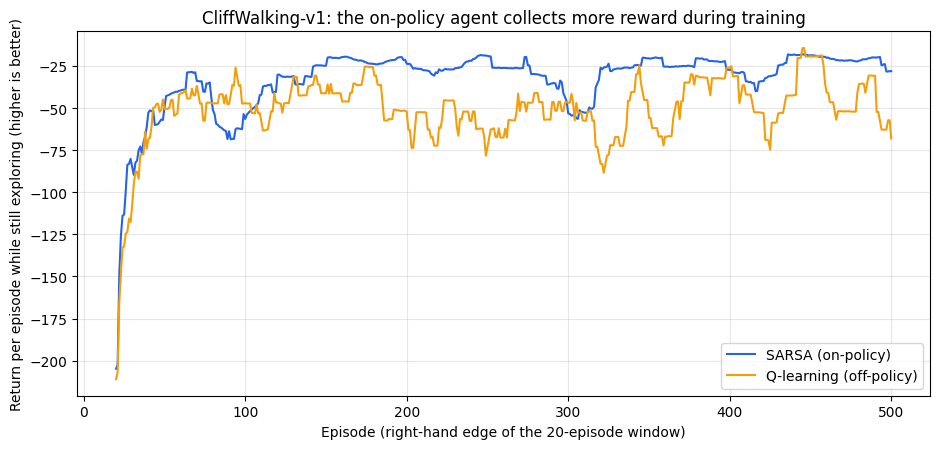


Mean grid row walked - SARSA: 0.67 | Q-learning: 2.14
(row 3 is the cliff row, row 2 runs right along its edge, row 0 is the far safe side)

What the measured numbers say:
- Q-learning's greedy path hugs the cliff. It is the OPTIMAL path: the shortest route.
- SARSA's greedy path detours away from the edge. It is longer, so it is NOT optimal.
- And yet SARSA collected MORE reward while training (-24.49 vs -47.96).
  This is the whole point of the lesson, and it is not a contradiction:
  * Q-learning's TD target assumes the next action will be the greedy one.
    But the agent is still epsilon-greedy, so 10% of the time it steps randomly -
    and one random step next to a cliff costs -100. Q-learning learns the value of
    a policy it is not actually following.
  * SARSA's target uses the action it really takes, so the exploration risk is priced
    into the values. It learns that walking beside a cliff while still exploring is
    expensive, and routes around it.

Rule of thumb: if 

In [3]:
# Comparison: train Q-LEARNING on the SAME environment with the SAME settings and seed.
# WHY it matters: exactly one line changed (max instead of the action actually taken). Everything
# else - environment, learning rate, epsilon, episode count, seed - is identical, so any difference
# in the result belongs to that one line and nothing else.

Q_qlearn, qlearn_returns = train("qlearning")

show_grid(Q_sarsa, "SARSA (on-policy) - greedy policy:")
print()
show_grid(Q_qlearn, "Q-learning (off-policy) - greedy policy:")

sarsa_path = greedy_rollout(Q_sarsa)
qlearn_path = greedy_rollout(Q_qlearn)
sarsa_late = sarsa_returns[-100:].mean()
qlearn_late = qlearn_returns[-100:].mean()

print(f"\nGreedy path length  - SARSA: {len(sarsa_path) - 1} steps | Q-learning: {len(qlearn_path) - 1} steps")
print(f"Average return over the last 100 TRAINING episodes (epsilon still 0.1):")
print(f"   SARSA      : {sarsa_late:7.2f}")
print(f"   Q-learning : {qlearn_late:7.2f}")

window = 20
# Put each average at the LAST episode of its own window, so the x axis is a real
# episode number rather than an index shifted by the window width.
window_end = np.arange(window, N_EPISODES + 1)
plt.figure(figsize=(9.5, 4.6))
plt.plot(window_end, np.convolve(sarsa_returns, np.ones(window) / window, mode="valid"),
         label="SARSA (on-policy)", color="#2563eb")
plt.plot(window_end, np.convolve(qlearn_returns, np.ones(window) / window, mode="valid"),
         label="Q-learning (off-policy)", color="#f59e0b")
plt.xlabel(f"Episode (right-hand edge of the {window}-episode window)")
plt.ylabel("Return per episode while still exploring (higher is better)")
plt.title("CliffWalking-v1: the on-policy agent collects more reward during training")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Which row does each greedy path spend most of its time in? Row 2 hugs the cliff, row 0 is safe.
sarsa_rows = [s // COLS for s in sarsa_path]
qlearn_rows = [s // COLS for s in qlearn_path]
print(f"\nMean grid row walked - SARSA: {np.mean(sarsa_rows):.2f} | Q-learning: {np.mean(qlearn_rows):.2f}")
print("(row 3 is the cliff row, row 2 runs right along its edge, row 0 is the far safe side)")

print("\nWhat the measured numbers say:")
if np.mean(qlearn_rows) > np.mean(sarsa_rows):
    print("- Q-learning's greedy path hugs the cliff. It is the OPTIMAL path: the shortest route.")
    print("- SARSA's greedy path detours away from the edge. It is longer, so it is NOT optimal.")
if sarsa_late > qlearn_late:
    print(f"- And yet SARSA collected MORE reward while training ({sarsa_late:.2f} vs {qlearn_late:.2f}).")
    print("  This is the whole point of the lesson, and it is not a contradiction:")
    print("  * Q-learning's TD target assumes the next action will be the greedy one.")
    print("    But the agent is still epsilon-greedy, so 10% of the time it steps randomly -")
    print("    and one random step next to a cliff costs -100. Q-learning learns the value of")
    print("    a policy it is not actually following.")
    print("  * SARSA's target uses the action it really takes, so the exploration risk is priced")
    print("    into the values. It learns that walking beside a cliff while still exploring is")
    print("    expensive, and routes around it.")
print("\nRule of thumb: if exploration continues while the agent is doing real work (a robot, a")
print("live system), the on-policy value is the one you actually experience. If you will train")
print("first and deploy a purely greedy policy afterwards, Q-learning's optimal path is the one")
print("you want. Same algorithm family, different question - so pick the one that matches yours.")

### 👁️ Read the figure

- **Both curves are training returns collected while ε is still 0.1** — one step in ten is
  random, for both agents. That is the honest setting for this comparison, because it is the
  setting the cliff punishes.
- **From about episode 120 onward the orange Q-learning curve sits below the blue SARSA
  curve, and it plunges far deeper.** Each downward excursion is a stretch of episodes in
  which exploratory steps kept knocking the agent into the cliff at -100 apiece. One fall
  moves a 20-episode average by -5, so the deepest dips (near episodes 190 and 320) are a
  dozen falls inside twenty episodes. Q-learning's greedy path runs along the cliff edge,
  so its random 1-in-10 steps are far more often fatal.
- **The gap is not subtle:** over the last 100 training episodes SARSA averaged **-24.5** and
  Q-learning **-48.0** — roughly twice the cost, from a one-symbol difference in the update.

**What it proves:** "optimal" depends on which policy you are asking about. Q-learning is
learning the value of the greedy policy, which really is the shorter route. SARSA is learning
the value of the policy it is actually running, exploration included — and while exploration
continues, SARSA's answer is the one that pays.


In [4]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Rummery, G. A. & Niranjan, M. (1994). *On-line Q-learning Using Connectionist Systems* (the SARSA report). Technical Report CUED/F-INFENG/TR 166, Cambridge University Engineering Department.
2. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6.4, Sarsa: On-policy TD Control.
4. Murphy, K. (2024). *Reinforcement Learning: An Overview*. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>
5. Yao, C., Chen, Y., Sun, Y. et al. (2025). *Group-Relative REINFORCE Is Secretly an Off-Policy Algorithm: Demystifying Some Myths About GRPO and Its Friends*. arXiv:2509.24203. <https://arxiv.org/abs/2509.24203> — the on-policy / off-policy line this lesson draws, re-argued at language-model scale.
6. Yan, R., Shen, X., Wachi, A. et al. (2025). *Offline Guarded Safe Reinforcement Learning for Medical Treatment Optimization Strategies*. arXiv:2505.16242. <https://arxiv.org/abs/2505.16242> — the "you cannot explore on a patient" constraint, treated as an offline-RL method with explicit out-of-distribution and safety constraints.
"""))

## 📚 References

1. Rummery, G. A. & Niranjan, M. (1994). *On-line Q-learning Using Connectionist Systems* (the SARSA report). Technical Report CUED/F-INFENG/TR 166, Cambridge University Engineering Department.
2. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6.4, Sarsa: On-policy TD Control.
4. Murphy, K. (2024). *Reinforcement Learning: An Overview*. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>
5. Yao, C., Chen, Y., Sun, Y. et al. (2025). *Group-Relative REINFORCE Is Secretly an Off-Policy Algorithm: Demystifying Some Myths About GRPO and Its Friends*. arXiv:2509.24203. <https://arxiv.org/abs/2509.24203> — the on-policy / off-policy line this lesson draws, re-argued at language-model scale.
6. Yan, R., Shen, X., Wachi, A. et al. (2025). *Offline Guarded Safe Reinforcement Learning for Medical Treatment Optimization Strategies*. arXiv:2505.16242. <https://arxiv.org/abs/2505.16242> — the "you cannot explore on a patient" constraint, treated as an offline-RL method with explicit out-of-distribution and safety constraints.


## 💬 Discuss

The measured cliff results: SARSA's greedy path is **17 steps**, Q-learning's is **13**; average
return over the last 100 *training* episodes was **−24.49 for SARSA** against **−47.96 for
Q-learning**; the mean grid row walked was **0.67 vs 2.14** (row 3 is the cliff). Argue these out.

1. Q-learning's path is provably optimal and it scored worse. State the conditions under which you
   would ship SARSA's longer path, and the conditions under which you would ship Q-learning's shorter
   one. "It depends on ε" is the start of the answer, not the answer.
2. Set ε = 0 after training and both agents walk their greedy path with no risk of a random step.
   Does that make SARSA's caution pointless? Name a real system where you cannot switch exploration
   off after deployment, and say why.
3. The sepsis case has no exploration at all — only historical records. Which of the two algorithms
   in this notebook is closer to what that situation needs, and what does the other one get wrong?
   Then argue the harder question: if you cannot explore and cannot trust your evaluation, should the
   system be built at all? Give the strongest version of both answers.


## 📝 Summary

You implemented **SARSA** and **Q-Learning** as one function with a single differing line, and ran
both on `CliffWalking-v1` — the Gymnasium version of Sutton & Barto's Example 6.6.

The measured result reproduces the textbook finding:

- **Q-learning** (off-policy) learned the **optimal** path, hugging the cliff edge. Its update
  target assumes the next action will be greedy.
- **SARSA** (on-policy) learned a **safer, longer** path. Its target uses the action really taken,
  so the cost of exploring next to a cliff is priced into the values.
- **SARSA collected more reward during training**, even though its path is not the optimal one —
  because the agent was still exploring, and Q-learning's optimal path is only optimal for an agent
  that has stopped.

### The takeaway

"Off-policy learns the optimal policy" and "off-policy performs better" are different claims. Which
algorithm you want depends on whether exploration continues while the agent is doing real work.
Both power real applications such as elevator scheduling, traffic-signal optimisation and
game-playing agents.

### Step Guide

**What this cell does:** Draws the two greedy policies on the actual cliff grid — the ASCII maps printed above, turned into one comparable picture with a shared colour scale.

**How to read it (weak Python OK):** Nothing is retrained. The cell only re-uses `Q_sarsa`, `Q_qlearn` and the two greedy paths already computed in the comparison section.

**What to expect in the output:** One figure with two 4x12 grids side by side and a single shared colour bar, then a short reading guide.

**If you feel lost:** Re-run the worked example and the comparison cell first so `Q_sarsa` and `Q_qlearn` exist, then run this cell again.


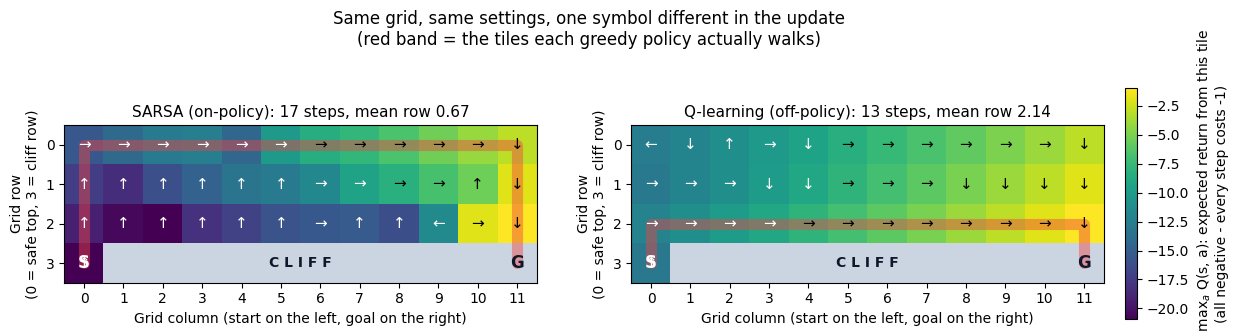

In [5]:
# Visual recap: the two greedy policies drawn on the real 4x12 cliff grid.
# Nothing is retrained here - this cell only redraws Q_sarsa and Q_qlearn, the two tables
# the comparison above already produced, so the ASCII maps become one comparable picture.

# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import numpy as np


def tile_values_and_mask(Q):
    """V(s) = value of the best action on that tile, plus a mask for tiles with no data."""
    # max over actions is exactly what the greedy policy would expect to collect from here.
    V = Q.max(axis=1).reshape(ROWS, COLS).astype(float)
    # The cliff tiles and the goal tile are never actually occupied (stepping into the cliff
    # teleports the agent home), so their Q rows are still all zeros. Zero is the LARGEST
    # number on this board, so drawing them would invent the best-looking tiles on the grid.
    unseen = np.all(np.isclose(Q, 0.0), axis=1).reshape(ROWS, COLS)
    for s in list(CLIFF_STATES) + [GOAL_STATE]:
        unseen[s // COLS, s % COLS] = True
    return np.ma.masked_array(V, mask=unseen)


tiles_sarsa = tile_values_and_mask(Q_sarsa)
tiles_qlearn = tile_values_and_mask(Q_qlearn)

# ONE colour scale across BOTH panels. Two heatmaps on independent scales would make the
# same colour mean two different numbers, which is the fastest way to mislead a reader.
vmin = float(min(tiles_sarsa.min(), tiles_qlearn.min()))
vmax = float(max(tiles_sarsa.max(), tiles_qlearn.max()))

# Greedy action per tile, drawn as the arrow it really is (0=up, 1=right, 2=down, 3=left).
arrow_glyph = {0: "\u2191", 1: "\u2192", 2: "\u2193", 3: "\u2190"}
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#cbd5e1")        # grey = no data: the cliff row and the goal tile

fig, axes = plt.subplots(1, 2, figsize=(14, 4.0))
panels = [
    (axes[0], tiles_sarsa, Q_sarsa, sarsa_path,
     f"SARSA (on-policy): {len(sarsa_path) - 1} steps, mean row {np.mean(sarsa_rows):.2f}"),
    (axes[1], tiles_qlearn, Q_qlearn, qlearn_path,
     f"Q-learning (off-policy): {len(qlearn_path) - 1} steps, mean row {np.mean(qlearn_rows):.2f}"),
]
for ax, tiles, Q_table, path, title in panels:
    image = ax.imshow(tiles, cmap=cmap, vmin=vmin, vmax=vmax)
    # Write the greedy arrow into every tile that actually has learned values.
    for row in range(ROWS):
        for col in range(COLS):
            if tiles.mask[row, col]:
                continue
            # Light text on dark cells, dark text on light cells, so arrows stay readable.
            shade = (tiles[row, col] - vmin) / (vmax - vmin + 1e-12)
            ax.text(col, row, arrow_glyph[int(np.argmax(Q_table[row * COLS + col]))],
                    ha="center", va="center", fontsize=11, zorder=4,
                    color="black" if shade > 0.6 else "white")
    # The tiles the greedy policy really walks, as a translucent band UNDER the arrows -
    # a solid line with markers would hide the very arrows the reader came to see.
    ax.plot([s % COLS for s in path], [s // COLS for s in path],
            color="#ef4444", linewidth=8, alpha=0.45, solid_capstyle="round", zorder=2)
    # Name the special tiles in words instead of leaving them blank.
    ax.text(0, ROWS - 1, "S", ha="center", va="center", fontsize=12, zorder=5,
            fontweight="bold", color="white")
    ax.text(COLS - 1, ROWS - 1, "G", ha="center", va="center", fontsize=12, zorder=5,
            fontweight="bold", color="#0f172a")
    ax.text((COLS - 1) / 2, ROWS - 1, "C L I F F", ha="center", va="center",
            fontsize=10, zorder=5, fontweight="bold", color="#0f172a")
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.set_xlabel("Grid column (start on the left, goal on the right)")
    ax.set_ylabel("Grid row\n(0 = safe top, 3 = cliff row)")
    ax.set_title(title, fontsize=11)

# One colour bar for both panels, because both panels use the same scale.
bar = fig.colorbar(image, ax=axes, fraction=0.022, pad=0.02, shrink=0.75)
bar.set_label("V(s) = max$_a$ Q(s, a): expected return from this tile\n(all negative - every step costs -1)")
fig.suptitle("Same grid, same settings, one symbol different in the update\n"
             "(red band = the tiles each greedy policy actually walks)", fontsize=12)
plt.show()


### 👁️ Read the figure

- **Both grids use ONE colour scale and share the colour bar on the right.** That is the only
  reason the comparison is legible: the same shade means the same number in both panels. The
  grey tiles are the cliff row and the goal, which the agent never actually occupies — their
  Q rows are still all zeros, and zero would have been the *brightest* value on this board.
- **Look at row 2, the tile-strip that runs along the cliff edge.** Q-learning has painted it
  teal-to-yellow, left to right: **-12, -11, -10 … -1**, which is exactly the true cost of
  the shortest path from each of those tiles. SARSA has painted the left two-thirds of the
  same strip dark purple: **-19, -21, -21, -18, -17 …** For SARSA, standing next to the
  cliff is worth roughly half as much.
- **The two red bands are the consequence.** Q-learning's greedy path (13 steps, mean row
  2.14) runs straight along that cliff edge. SARSA's (17 steps, mean row 0.67) climbs to the
  top row first and takes the long way round. Neither path was chosen by hand; both are the
  greedy readout of the table beside them.
- **Neither table is wrong.** SARSA's update uses the action it will *really* take, and one
  action in ten is random, so a tile beside a cliff genuinely is expensive while exploration
  continues — the start tile is worth **-20.9** to SARSA and **-13.0** to Q-learning. That
  -20.9 is not pessimism, it is the price of ε = 0.1 next to a 100-point drop.

**What it proves:** one symbol in the TD target — `Q(s', a')` versus `max_a Q(s', a)` —
changes what the agent believes about the world, not just how fast it learns. On-policy SARSA
values the policy you are running; off-policy Q-learning values the policy you would run if
you stopped exploring. Choose by asking which of those two you will actually deploy.


## ⚠️ Where this breaks

**The assumption that has to hold, for SARSA:** the exploration you use while learning is the
exploration you will live with. SARSA prices your ε into the values. Change ε and the answer changes.

- **SARSA's answer is not "the optimal policy".** It is the best policy *given that you keep taking
  random actions 10% of the time*. That is a feature on a cliff and a bug if you intend to deploy
  greedily — you will have paid for caution you no longer need. As ε → 0, SARSA's solution converges
  to Q-learning's; the gap you measured above is entirely manufactured by ε = 0.1.
- **Q-learning's answer assumes an exploration-free future.** Its −47.96 training return is not a
  defect in the algorithm; it is the correct consequence of optimising for a policy it is not
  following. Quoting a training curve as deployed performance hides this.
- **Neither one handles "learn from someone else's data".** Both need to act. The sepsis case, the
  DiDi logs from lesson 03, and any project where you have history but cannot experiment, need
  *offline* RL and off-policy evaluation — a different toolkit with different failure modes, and one
  where the honest answer is often "the confidence interval on this estimate is too wide to act on".
- **Both are tabular here.** 48 states. Nothing in this comparison survives contact with a state
  space you cannot enumerate without the function approximation of Unit 3.
- **Cheaper alternative:** if the risk you are routing around is *known and expressible* — "never
  come within one tile of the cliff", "never exceed this dose" — encode it as a hard constraint on the
  action set rather than hoping the agent learns to respect it. A constraint you can point to in code
  is worth more in a safety review than a value function that happens to avoid the edge.


## Closing Takeaway

**Teaching takeaway:** SARSA learns from the action the agent actually takes, so it reflects the behavior policy more directly than Q-learning does.

**If students remember one idea:** On-policy learning means the update follows the path the current policy really experienced.

**Quick check before moving on:**
- Can you explain the structural difference between the SARSA and Q-learning update targets?
- Can you describe why SARSA can behave more cautiously during exploration?

**Bridge to the next step:** After this comparison, students can better appreciate when prediction and control updates should reflect actual behavior versus greedy targets.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**At a glance:** The next cell uses a **random** policy on FrozenLake. **Not reaching the goal tile `G` is normal and intended**—the point is to see the **API loop** (state → action → reward → next state) in motion, not to prove a solved policy. If the episode ends in a hole or times out, the demo is still doing its job.

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.


Teaching note: random FrozenLake rollouts may not reach G—this is expected. Read state→action→reward over time, not 'did it win?'.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=3 | term=True | trunc=False


objc[58886]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113d08138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1142049c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[58886]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113d08188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114204a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[58886]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x113d07c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114204a68). T

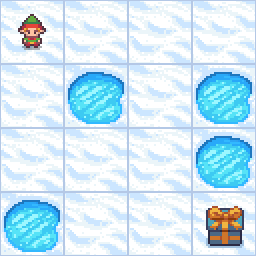

In [6]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

print(
    "Teaching note: random FrozenLake rollouts may not reach G—this is expected. "
    "Read state→action→reward over time, not 'did it win?'."
)

# Install the visual-demo dependencies quietly (safe to rerun; already-installed packages are skipped).
%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
# WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
#       and only then download it; finally put its folder on Python's import path.
# WHY:  searching only the PARENTS of the working directory breaks the moment you open this
#       notebook from the repository root - there the helper sits in a child folder, not a
#       parent - and on Colab there is no repository at all. This does not care where you
#       started the kernel from.
_HELPER_C9 = "course09_step_viz.py"
_chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
_course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
if _course09 is None:                      # opened from the repo root, or from another course
    _course09 = next((d / "Course 09" for d in _chain_c9
                      if (d / "Course 09" / _HELPER_C9).exists()), None)
if _course09 is None:                      # Google Colab, or a stray copy of this notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
            "Course%2009/" + _HELPER_C9, _HELPER_C9)
    except Exception as _e:
        raise FileNotFoundError(
            f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
            "Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
            f"re-run this cell. (underlying error: {_e})") from None
    _course09 = pathlib.Path.cwd()

# Put that folder on Python's import path so the helper imports from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
